FIRST 5 ROWS
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0

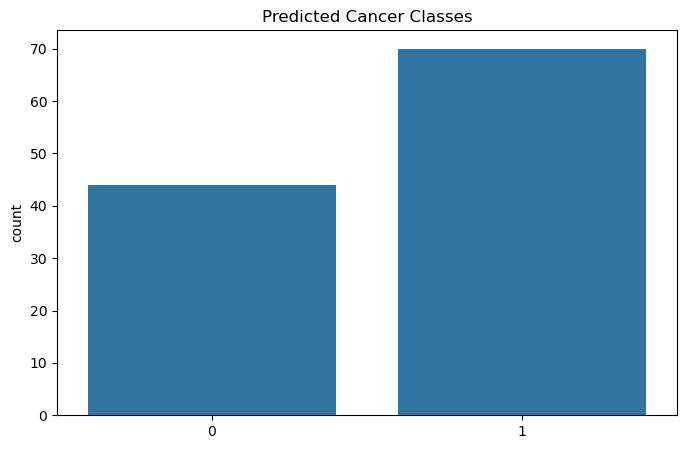

In [5]:
# ==========================================
# SVM - BREAST CANCER CLASSIFICATION
# ==========================================

# ------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------

import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# CREATE FOLDERS
# ==========================================

os.makedirs(
    "../../../datasets/cleaned/svm",
    exist_ok=True
)

os.makedirs(
    "../../../datasets/processed/svm",
    exist_ok=True
)

# ==========================================
# 1. LOAD DATASET
# ==========================================

data = load_breast_cancer()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["target"] = data.target

print("FIRST 5 ROWS")
print(df.head())

# ==========================================
# 2. CLEANING
# ==========================================

# Remove duplicates

df = df.drop_duplicates()

# Remove missing values

df = df.dropna()

print("\nMISSING VALUES")
print(df.isnull().sum())

# ==========================================
# 3. SAVE CLEANED DATASET
# ==========================================

df.to_csv(
    "../../../datasets/cleaned/svm/cleaned_breast_cancer.csv",
    index=False
)

print("\nCLEANED DATASET SAVED")

# ==========================================
# 4. FEATURE SELECTION
# ==========================================

X = df.drop(
    "target",
    axis=1
)

y = df["target"]

# ==========================================
# 5. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# 6. FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

# ==========================================
# 7. SAVE PROCESSED DATASETS
# ==========================================

pd.DataFrame(X_train).to_csv(
    "../../../datasets/processed/svm/X_train.csv",
    index=False
)

pd.DataFrame(X_test).to_csv(
    "../../../datasets/processed/svm/X_test.csv",
    index=False
)

print("\nPROCESSED DATA SAVED")

# ==========================================
# 8. CREATE MODEL
# ==========================================

model = SVC(
    kernel="linear"
)

# ==========================================
# 9. TRAIN MODEL
# ==========================================

model.fit(
    X_train,
    y_train
)

print("\nMODEL TRAINED SUCCESSFULLY")

# ==========================================
# 10. PREDICTIONS
# ==========================================

predictions = model.predict(
    X_test
)

print("\nPREDICTIONS")
print(predictions[:10])

# ==========================================
# 11. EVALUATION
# ==========================================

accuracy = accuracy_score(
    y_test,
    predictions
)

print("\nACCURACY")
print(accuracy)

print("\nCONFUSION MATRIX")
print(confusion_matrix(
    y_test,
    predictions
))

print("\nCLASSIFICATION REPORT")
print(classification_report(
    y_test,
    predictions
))

# ==========================================
# 12. SAVE PREDICTIONS
# ==========================================

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

results.to_csv(
    "../../../datasets/processed/svm/predictions.csv",
    index=False
)

print("\nPREDICTIONS SAVED")

# ==========================================
# 13. VISUALIZATION
# ==========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x=predictions
)

plt.title("Predicted Cancer Classes")

plt.show()

# ==========================================
# END
# ==========================================